In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt 
import numpy as np

In [2]:
df_flood_scaled = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/scaled/flood_scaled.csv')
df_flood_unscaled = pd.read_csv('/Users/veron/Desktop/natural disasters project/data/clean/cleaned_flood.csv')

In [3]:
df_flood_scaled.describe()

,Unnamed: 0,duration_days,Total Deaths,Total Affected,Fatality Rate,Damages Adjusted
count,5112.000000,5112.000000,5112.000000,5112.000000,5112.000000,5112.000000
mean,2555.500000,0.050635,0.101388,0.027808,0.144315,0.474134
std,1475.851619,0.821048,1.195217,0.856735,0.970545,1.572487
min,0.000000,-1.000000,-2.019622,-2.669183,-1.590071,-2.010296
25%,1277.750000,-0.500000,-0.456483,-0.498255,-0.433554,-0.379333
50%,2555.500000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3833.250000,0.500000,0.543517,0.501745,0.566446,0.620667
max,5111.000000,3.196159,7.319595,3.265053,4.525604,12.034248


In [4]:
df_flood_scaled.head()

,Unnamed: 0,duration_days,Total Deaths,Total Affected,Fatality Rate,Damages Adjusted,Continent
0,0,-1.0,0.814213,0.000000,0.577189,8.747089,Americas
1,1,0.0,0.000000,0.000000,-0.006504,3.454437,Africa
2,2,0.0,0.000000,2.229841,-0.825273,8.747089,Asia
3,3,-1.0,2.312216,0.741694,0.945041,9.416162,Americas
4,4,-1.0,-1.346414,-1.281868,-0.262946,4.456598,Americas


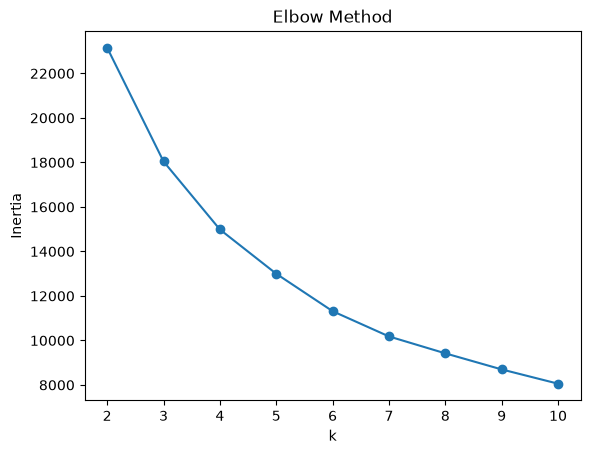

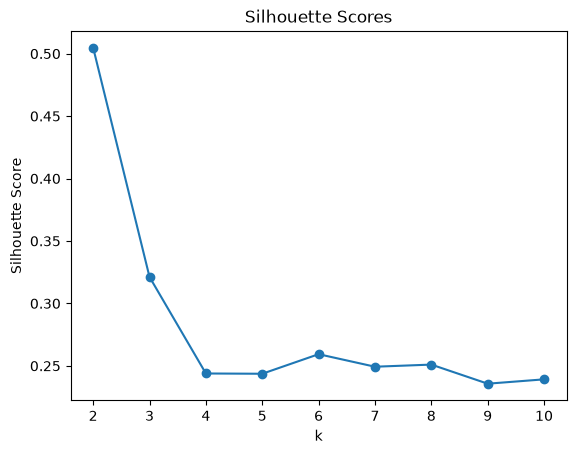

In [5]:
flood_features = ['Total Deaths', 'Total Affected', 'duration_days', 'Fatality Rate', 'Damages Adjusted']
X = df_flood_scaled[flood_features]

inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(X, labels))

# Elbow plot
plt.plot(k_range, inertias, marker='o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Silhouette plot
plt.plot(k_range, silhouette_scores, marker='o')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

### It appears k = 2-3 is the best value.

### Try k = 2

In [6]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_flood_scaled['cluster'] = kmeans.fit_predict(df_flood_scaled[flood_features])

df_flood_scaled.groupby('cluster')[flood_features].mean()

,Total Deaths,Total Affected,duration_days,Fatality Rate,Damages Adjusted
cluster,,,,,
0,0.001575,-0.008507,0.090646,0.103789,0.082223
1,1.122986,0.399497,-0.358891,0.559104,4.485406


### Next, try k = 3.

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_flood_scaled['cluster'] = kmeans.fit_predict(df_flood_scaled[flood_features])

df_flood_scaled.groupby('cluster')[flood_features].mean()

,Total Deaths,Total Affected,duration_days,Fatality Rate,Damages Adjusted
cluster,,,,,
0,1.623986,0.484327,0.354210,0.984968,0.483975
1,-0.426165,-0.136162,-0.009537,-0.136794,0.056117
2,0.674937,0.271675,-0.393455,0.334899,5.621772


In [8]:
df_flood_scaled['cluster'].value_counts()

cluster
1    3660
0    1157
2     295
Name: count, dtype: int64

In [15]:
df_flood_unscaled['cluster'] = df_flood_scaled['cluster']
reference_cpi = (df_flood_unscaled.loc[df_flood_unscaled['Year'] == df_flood_unscaled['Year'].max(), 'CPI']).mean()
df_flood_unscaled['fatality_rale_unscaled'] = (df_flood_unscaled['Total Deaths'] / df_flood_unscaled['Total Affected']).clip(upper=1.0)

df_flood_unscaled['Damages Adjusted'] = df_flood_unscaled["Total Damages ('000 US$)"] * (reference_cpi / df_flood_unscaled['CPI'])

df_flood_unscaled.groupby('cluster')[['duration_days', 'Total Deaths', 'Total Affected', "Total Damages ('000 US$)", 'fatality_rale_unscaled', 'Damages Adjusted']].median()

,duration_days,Total Deaths,Total Affected,Total Damages ('000 US$),fatality_rale_unscaled,Damages Adjusted
cluster,,,,,,
0,7.0,65.0,88825.0,140500.0,0.000917,207544.796452
1,3.0,8.0,6000.0,27000.0,0.000722,37446.922143
2,0.0,34.0,30000.0,45000.0,0.000820,206308.348291


In [13]:
df_flood_unscaled['Damages Adjusted'].describe()

count    1.717000e+03
mean     7.094971e+05
std      2.596913e+06
min      4.661165e+00
25%      1.131938e+04
50%      8.153445e+04
75%      3.936625e+05
max      4.763152e+07
Name: Damages Adjusted, dtype: float64

In [10]:
df_flood_unscaled.groupby('cluster')['Damages Adjusted'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,599.0,1.374663e+06,4.073213e+06,34.860369,35796.267838,207544.796452,805305.621149,4.763152e+07
1,1003.0,3.005024e+05,1.003475e+06,4.661165,5780.990147,37446.922143,190946.304609,1.433167e+07
2,115.0,8.119960e+05,1.351358e+06,1278.342671,56901.870770,206308.348291,960899.862376,1.013417e+07


In [11]:
df_flood_scaled.groupby('cluster')['Damages Adjusted'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,1157.0,0.483975,0.910928,-1.691845,-0.199038,0.226432,0.964496,3.829941
1,3660.0,0.056117,0.724618,-2.010296,-0.416316,-0.137445,0.317121,3.239380
2,295.0,5.621772,2.103571,2.714450,3.998709,5.255148,6.962534,12.034248


In [17]:
df_flood_unscaled.groupby('cluster')['Damages Adjusted'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,599.0,1.374663e+06,4.073213e+06,34.860369,35796.267838,207544.796452,805305.621149,4.763152e+07
1,1003.0,3.005024e+05,1.003475e+06,4.661165,5780.990147,37446.922143,190946.304609,1.433167e+07
2,115.0,8.119960e+05,1.351358e+06,1278.342671,56901.870770,206308.348291,960899.862376,1.013417e+07


## Clusters and interpretations (unscaled):
- Cluster 0: Long-duration floods (longest duration, most severe, most damages)
- Cluster 1: Nuisance floods (moderate duration, least severe, moderate damages)
- Cluster 2: Flash floods (shortest duration, moderate severity, lowest damages)

Discrepancy explained by extreme outliers that inflate raw mean. 

## Clusters and interpretations (scaled):
- Cluster 0: Long-duration floods (longest duration, most severe, moderate damages)
- Cluster 1: Nuisance floods (moderate duration, least severe, least damages)
- Cluster 2: Flash floods (shortest duration, moderate severe, most damages)

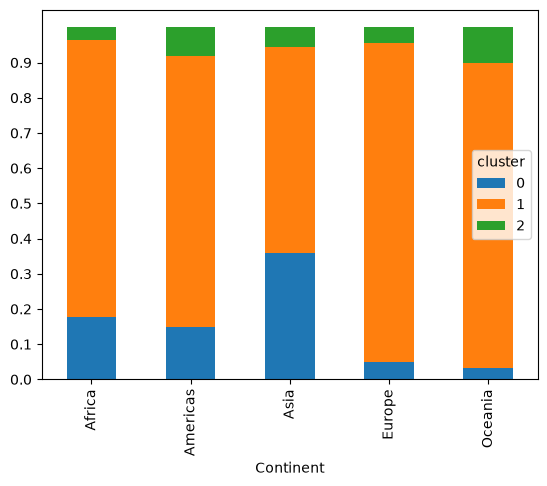

In [12]:
y_ticks = np.arange(0, 1, 0.1)

pd.crosstab(df_flood_scaled['Continent'], df_flood_scaled['cluster'], normalize='index').plot(kind='bar', stacked=True).set_yticks(y_ticks)
# For cluster 0, it appears asia is significantly higher, and europe is significantly lower
# cluster 1, africa is very small, yet its cluster 0 still on par with americas and oceania, whose cluster 1 is a lot bigger. europe's is the largest here, makes sense as cluster 0 is the smallest for europe
# cluster 2 (doesn't really matter)

# so, asia has the most deadly earthquakes (makes sense)
# africa has the littlest damages despite having on par deadly earthquakes
# europe's earthquakes not as deadly, but highest damages 

- Asia has the highest share of long-duration, high-fatality floods (~36%), with Africa also notably elevated (~18%) relative to the Americas, Europe, and Oceania.
- Europe and Oceania both see the highest share of typical/low-impact floods (~87-90%) — but despite this similarity, Oceania has roughly double Europe's share of high-damage, flash-flood-type events (~10% vs ~5%), indicating a distinct economic risk profile even where flood severity in human terms looks comparably low.